In [1]:
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 32회 ADP 복원

## 기계학습 (60점)

### 데이터 설명 
- 데이터 설명 : 시간대별 발전량에 대한 데이터이다

- 1-1) 결측치 처리 방안 2개 제시하고, 통계량으로 비교하고, 어떤걸 사용하는게 좋을지 제시해라
- 1-2) 이상치 판단하고, 처리해야할지 판단해서 제시하라
- 1-3) 위의 처리를 마친 데이터로 EDA를 실행하는데, 종속변수의 데이터 값을 기준으로 독립변수들이 다름을 확인해라
- 1-4) 상관행렬 구하고, 상관행렬을 주성분분석하여 새로운 설명변수를 만드는데 사용할 수 있는지 판단하여 제시해라

2-1)클래스 불균형이 존재하는데 해결할 수 있는 방안 2가지를 제시
2-2)클래스 불균형 상황에서 분류모델의 성능을 평가하기 위한 방안 3가지를 제시(10점)
2-3)위에서 제시한 2가지 불균형 처리 방법을 사용하고, 3가지 평가지표로 결과를 평가
*행 넘버의 5의 배수로 train과 test 셋 분리
*종속변수가 0,1,2,3 4개 값을 가지는데, 0과 1,2,3의 2가지 범주로 나누어서 모델 학습 및 평가 진행


3-1) 1에서 전처리한 데이터를 바탕으로 종속변수에서 0을 제외한 1,2,3의 데이터만 가지고 학습 및 평가 진행해라. 이 때 모델은 3개 사용.
*동일하게 행 넘버의 5의 배수로 train과 test 셋 분리
3-2) 위에서 학습한 모델과 평가지표를 바탕으로 간염여부를 판단할 수 있는 지표? 정보?를 제시해라


4) 지하철 이용객, 기상 데이터(aws.csv)
- melt 함수 사용
- 강수량에 대해 0으로 결측치 대치
- 기초통계량 확인하여 제시
- 토,일에 해당하는 데이터 weeday 1로, 나머지 0으로 *(weekday의 단어 뜻을 모르나..? 왜 이런 변수명이..)
- 두 개 csv merge

- 1)user 컬럼과 기후를 나타내는 컬럼들의 상관관계를 분석하고, 주말여부에 따른 user 변수의 차이를 검증하라.

- 2)선형 회귀모델과 머신러닝 모델을 사용하여 user 변수를 예측, 평가하라.

 정말 화나는건 기상 데이터는 날짜별 시간대별 강수량, 습도 등이 적혀있는 데이터인데 2021-05-05 13시에  해당 데이터가 없어서 merge하는 과정에서 생긴 결측치가 있었습니다. 혹시 코드 수행을 잘 못했는지 디버깅 하다가 시간을 20분 추가로 날렸습니다... 크나큰 패착... inner 조인을 해야했다 생각이 들기도 하지만, 어쨋든 지하철 이용객이 Main Table이니 Left join한 건 맞다고 봅니다. 

이게 악질적으로 느껴졌던건 기상데이터는 몇 만행이고 실제로 중간에 결측치라고 표현되지도 않습니다.  다음과 같이 표현되기 때문이죠.


## 전처리 

## 1-1 date 컬럼을 이용하여 3개의 파생변수를 만들어라
- 1. month : 월 정보
- 2. day : 일자 정보 ( 월요일 ~ 토요일 : 1 ~ 6, 일요일 : 0)
- 3. nsd : 일자의 자정으로부터 소요된 총 분 (minute)

In [83]:
df = pd.read_csv("./data/32/adp32_p1.csv")
df.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    35040 non-null  object 
 1   Kwh     35040 non-null  float64
 2   LaCR    35040 non-null  float64
 3   LeCR    35040 non-null  float64
 4   co2     35040 non-null  float64
 5   LaF     35040 non-null  float64
 6   LeF     35040 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.9+ MB


In [85]:
df['date'] = pd.to_datetime(df['date'], format = '%d/%m/%Y %H:%M')
df['month'] = df['date'].dt.month
df['day'] = (df['date'].dt.dayofweek +1) % 7
df['nsd'] = df['date'].dt.hour * 60 + df['date'].dt.minute
display(df.head())

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75


- dayofweek : 월-일 (0~6)
- % : 나누고 나머지, // : 몫
- 그냥 나누기 : /

## 1-2 두개의 파생변수를 추가하라
- 파생변수 명 ind11 : month, day, nsd 컬럼의 합이 11의 배수이고, 22의 배수가 아니라면 1의 값 그 외는 0
- 파생변수 명 ind22 : month, day, nsd 컬럼의 합이 22의 배수이면 1 그외는 0

In [ ]:
# 방법 1

In [86]:
df['ind11'] = np.where(((df['month'] + df['day'] + df['nsd']) % 11 == 0) &\
         ((df['month'] + df['day'] + df['nsd']) % 22 != 0),1, 0)
df['ind22'] = np.where(((df['month'] + df['day'] + df['nsd']) % 22 == 0),1, 0)
df.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75,1,0


In [10]:
# astype('int')
# 그 외 : ['float', 'str', 'bool', 'category']

In [92]:
# 방법 2
# bool 형식을 int형으로 바꾸면 1과 0으로 바뀜 
df['ind11'] = (((df['month']+df['day']+df['nsd'])%11 == 0) \
               & ((df['month']+df['day']+df['nsd'])% 22 != 0)).astype('int')


df['ind22'] = ((df['month']+df['day']+ df['nsd']) % 22 == 0).astype('int')
display(df.head())

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75,1,0


In [87]:
# pd.crosstab()은 두 개 이상의 범주형 변수의 관계를 교차표(빈도표)로 보여줌
pd.crosstab(df['ind11'], df['ind22'])

ind22,0,1
ind11,,
0,31858,1583
1,1599,0


## 1-3 한개의 파생변수를 추가하라
- 파생변수명 Kwh8 : Kwh컬럼의 값이 4.1 초과일 경우 1, 그 외 0

In [88]:
df['Kwh8'] = (df['Kwh']>4.1).astype('int')
df.head()

# df['Kwh8'] = df['Kwh'].map(lambda x:1 if x >4.1 else 0)

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22,Kwh8
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15,0,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30,0,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45,0,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60,0,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75,1,0,0


## 1-4 전처리를 완료한 데이터를 기준으로 EDA를 실시하라. (시각화 포함)

In [98]:
# EDA는 나중에 하기 
# 이상치와 결측치 확인해보기 

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    35040 non-null  datetime64[ns]
 1   Kwh     35040 non-null  float64       
 2   LaCR    35040 non-null  float64       
 3   LeCR    35040 non-null  float64       
 4   co2     35040 non-null  float64       
 5   LaF     35040 non-null  float64       
 6   LeF     35040 non-null  float64       
 7   month   35040 non-null  int64         
 8   day     35040 non-null  int64         
 9   nsd     35040 non-null  int64         
 10  ind11   35040 non-null  int64         
 11  ind22   35040 non-null  int64         
 12  Kwh8    35040 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(6)
memory usage: 3.5 MB


In [15]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Kwh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
LaCR,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
LeCR,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
co2,35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
LaF,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
LeF,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
month,35040.0,6.526027,3.447901,1.0,4.00,7.00,10.0000,12.00
day,35040.0,2.994521,2.000021,0.0,1.00,3.00,5.0000,6.00
nsd,35040.0,712.500000,415.675572,0.0,356.25,712.50,1068.7500,1425.00
ind11,35040.0,0.045634,0.208692,0.0,0.00,0.00,0.0000,1.00


In [23]:
# 불균형 클래스인지 확인 → 향후 모델링에 영향 줌(e.g. 오버샘플링 필요 여부)

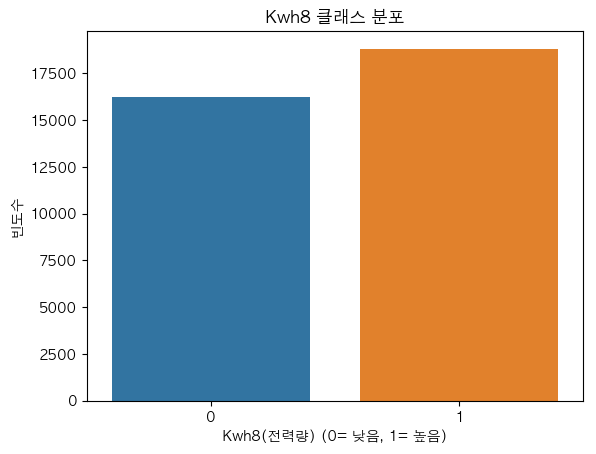

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Kwh8', data = df)
plt.title('Kwh8 클래스 분포')
plt.xlabel('Kwh8(전력량) (0= 낮음, 1= 높음)')
plt.ylabel('빈도수')
plt.show()

In [25]:
display(df['Kwh8'].value_counts(normalize=True).map("{:.1%}".format))
print("불균형 클래스가 아님을 확인")

1    53.7%
0    46.3%
Name: Kwh8, dtype: object

불균형 클래스가 아님을 확인


In [26]:
# 수치형 변수와 Kwh8의 관계 : Boxplot
df_num = df.select_dtypes(include='number')

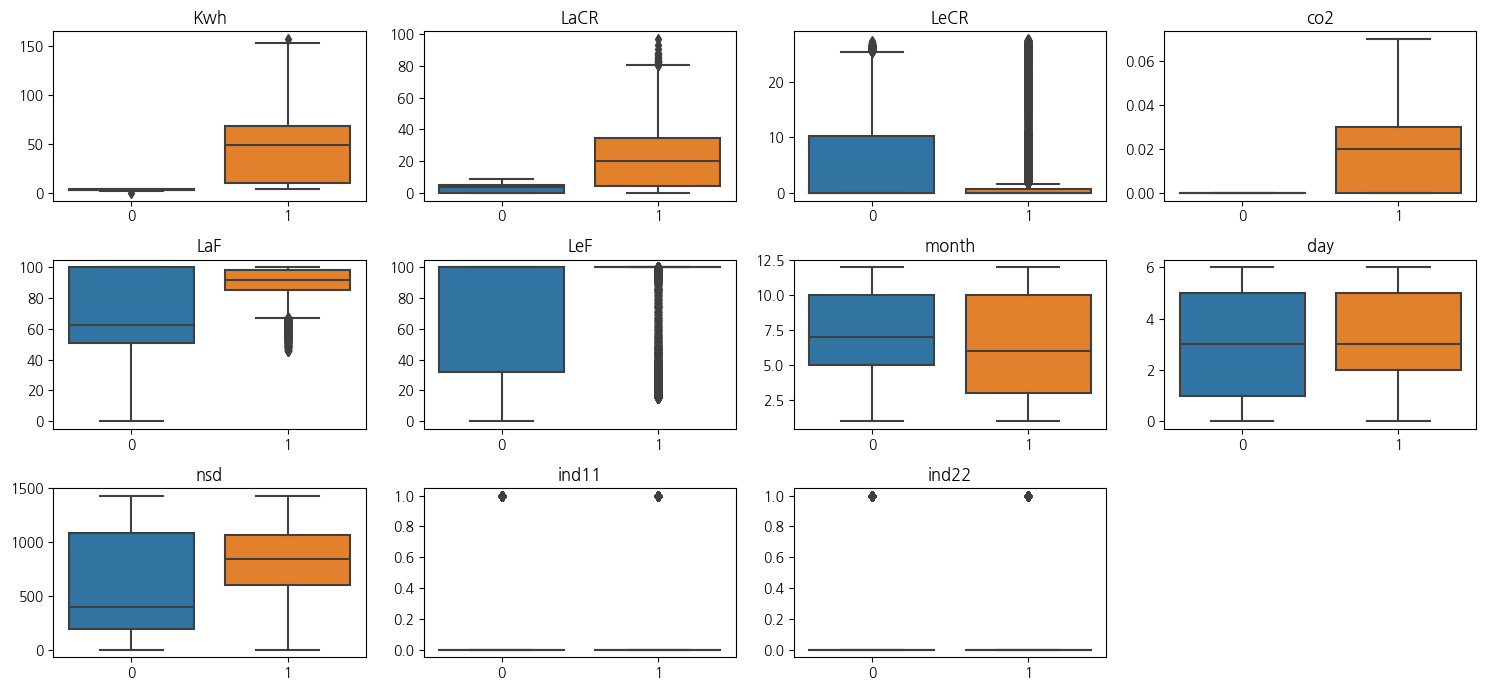

In [27]:
fig,axes = plt.subplots(3,4,figsize=(15,7))

target_col = df_num.drop(columns = 'Kwh8').columns.tolist()
for i,ax in enumerate(axes.flat[:-1]):
    target_df = df[['Kwh8',target_col[i]]]
    sns.boxplot(x= 'Kwh8',y = target_col[i] ,data = df, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(target_col[i])
    
axes.flat[-1].remove()
plt.tight_layout()
plt.show()

In [32]:
# Kwh8 = 0인 그룹에서 LaF, nsd의 평균이 낮다 
# Kwh8 = 1인 그룹에서 LaF, nsd의 평균이 높다

# LeF와 LeCR에 이상치가 매우 많음을 확인할 수 있다.

# LeF는 Kwh8 = 1일 때, 거의 100에 치우쳐져 있으며, 이상치가 매우 많음을 알 수 있다.

In [34]:
# nsd vs Kwh8을 보면 
# Kwh8 = 1인 경우가 대체로 낮 12시 ~ 오후 시간대(720분 이후)에 몰려 있으면
# 전력 피크 타임은 오후 시간대와 관련 있다고 볼 수 있다.

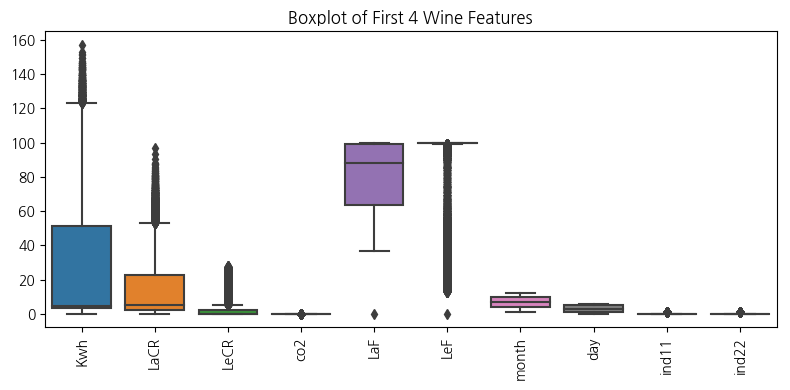

In [31]:
plt.figure(figsize = (8,4))

sns.boxplot(data=df_num.drop(columns = ['Kwh8', 'nsd']))  # data를 무조건 써줘야함

plt.xticks(rotation=90)  # ← 핵심 줄!
plt.title("Boxplot of First 4 Wine Features")
plt.tight_layout()
plt.show()

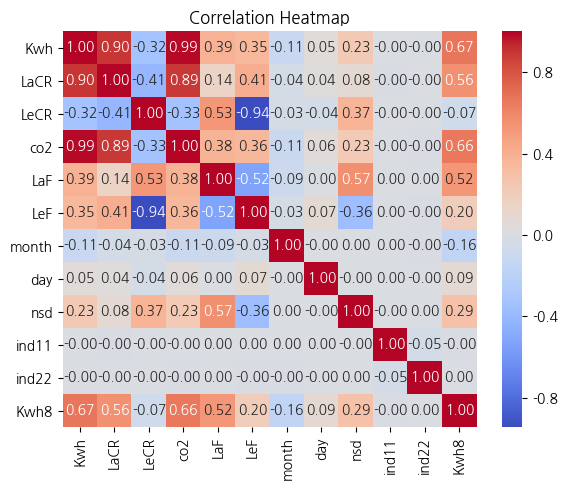

In [35]:
corr = df.select_dtypes('number').corr(method='pearson')  # 또는 'spearman', 'kendall'

# 3. 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [44]:
 # Kwh vs co2 = 0.99로 매우 강한 상관관계를 가짐을 알 수 있으며 , LaCR vs co2 = 0.89로 강한 상관관계를 가짐을 알 수 있다.
# LeCR vs LeF = -0.94로 강한 음의 상관관계를 가진다. 

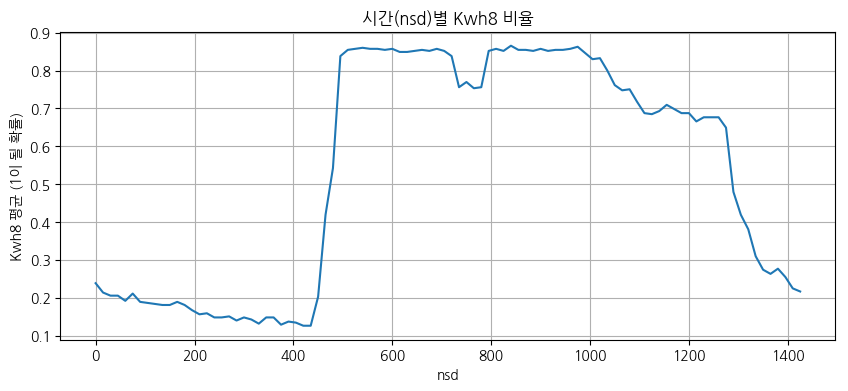

In [36]:
temp = df.groupby('nsd')['Kwh8'].mean()

plt.figure(figsize=(10,4))
temp.plot()
plt.title('시간(nsd)별 Kwh8 비율')
plt.ylabel('Kwh8 평균 (1이 될 확률)')
plt.grid(True)
plt.show()

In [50]:
# 시간에 따라 Kwh8이 1이 될 확률, 즉 비율을 보여주는 그래프
# 약 500분에 전력양이 급등하며 500~1000분 대에 높은 발전량 비율을 보여줌을 알 수 있다.  

## 1-5 Kwh8을 종속 변수로 하고 Kwh를 제거하라. 서포트 벡터 머신과 랜덤 포레스트를 사용하여 분류모델을 학습하고 평가하라. confusion matrix를 해석하라

- 파생변수 ind11 칼럼 값이 1인 데이터만 훈련에 사용할 것, ind22 칼럼의 값이 1인 데이터만 테스트에 사용할 것
- 모든 모델링은 그리드 서치를 통해서 최적 파라미터를 산출할 것.(각 모델의 파라미터는 3개 이하로 설정)
- (그리드 서치 : 하이파라미터 조합을 자동으로 찾는 방법)

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

In [90]:
# Pipeline : 머신러닝 모델 학습과 전처리 과정을 자동으로 묶어서 순차적으로 실행해주는 도구

In [91]:
train = df[df.ind11 == 1]
test = df[df.ind22 == 1]

train_x = train.drop(columns = ['Kwh','Kwh8','date'])
train_y = train['Kwh8']

test_x = test.drop(columns = ['Kwh','Kwh8','date'])
test_y = test['Kwh8']

In [92]:
def rfc_modeling(train_x, train_y):
    rfc = RandomForestClassifier(random_state=2025)
    param_grid = {
        'n_estimators':[100,50], # 트리 개수 (많을수록 안정적이지만 느려짐)
        'min_samples_split':[2,5], # # 노드를 나누기 위한 최소 샘플 수
        'min_samples_leaf':[1,3],  # 리프 노드에 있어야 할 최소 샘플 수 
    }
    
    grid_search = GridSearchCV(rfc, param_grid, refit = True, cv = 3)
    # refit = True :그리드서치가 끝난후, 가장 좋은 파라미터 조합으로 전체 데이터를 다시 학습
    # cv : 데이터를 3등분 해서 총 3번 모델을 학습하고 검증, 2개는 학습용,1개는 검증용
    # 번갈아가면서 검증용 설정, 총 3개의 모델, 각 파라미터 조합 실험
    grid_search.fit(train_x, train_y)
    return grid_search

def svc_modeling(train_x, train_y):
    svc = SVC()
    param_grid = {
        'svc__C': [1,10],  # 마진 너비(크면 과적합)
        'svc__kernel':['linear','rbf'], # 커널 타입
        'svc__tol':[0.001,0.01],    # 수렴조건
    } # 언더바 두 개 __ 의 의미 : 파이프라인에서 svc라는 단계에 있는 모델의 파라미터 설정
    
    pipeline = Pipeline([('scaler', StandardScaler()),('svc',SVC())])
    
    grid_search = GridSearchCV(pipeline, param_grid,refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

# 또다른 분류모델 : KNN, 로지스틱 회귀

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


def knn_modeling(train_x, train_y):
    knn = KNeighborsClassifier()
    param_grid = {
        'knn__n_neighbors': [3, 5, 7],     # 이웃의 수
        'knn__weights': ['uniform', 'distance'],  # 거리 가중치 방식
        'knn__p': [1, 2]                   # 거리 측정 방식 (1: Manhattan, 2: Euclidean)
    }

    pipeline = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
    
    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search


def lr_modeling(train_x, train_y):
    lr = LogisticRegression(max_iter=1000)
    param_grid = {
        'lr__C': [0.01, 0.1, 1],        # 정규화 강도
        'lr__penalty': ['l2'],         # 규제 방식
        'lr__solver': ['lbfgs', 'saga']  # 최적화 알고리즘
    }

    pipeline = Pipeline([('scaler', StandardScaler()), ('lr', lr)])
    
    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

# 인공신경망

In [94]:
from sklearn.neural_network import MLPClassifier

def mlp_modeling(train_x, train_y):
    param_grid = {
        'mlp__hidden_layer_sizes': [(50,), (100,)],  # 은닉층 크기
        'mlp__activation': ['relu', 'tanh'],
        'mlp__alpha': [0.0001, 0.001],               # L2 정규화
    }

    pipeline = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(max_iter=100, random_state=42))])
    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

from xgboost import XGBClassifier

def xgb_modeling(train_x, train_y):
    param_grid = {
        'xgb__n_estimators': [50, 100],
        'xgb__max_depth': [3, 5],
        'xgb__learning_rate': [0.1, 0.3]
    }

    pipeline = Pipeline([('scaler', StandardScaler()), \
                         ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])
    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

# 배깅 앙상블 (BaggingClassifier + DecisionTree)

In [95]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

def bagging_modeling(train_x, train_y):
    param_grid = {
        'bag__n_estimators': [50, 100],
        'bag__max_samples': [0.6, 0.8],
        'bag__base_estimator__max_depth': [3, 5]
    }

    base_tree = DecisionTreeClassifier(random_state=42)
    pipeline = Pipeline([('scaler', StandardScaler()), ('bag', BaggingClassifier(base_estimator=base_tree, random_state=42))])
    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

In [97]:
rfc = rfc_modeling(train_x, train_y)
svc = svc_modeling(train_x, train_y)
rfc_pred = rfc.predict(test_x)
svc_pred = svc.predict(test_x)

In [98]:
knn = knn_modeling(train_x, train_y)
lr = lr_modeling(train_x, train_y)
knn_pred = knn.predict(test_x)
lr_pred = lr.predict(test_x)

In [99]:
mlp = mlp_modeling(train_x, train_y)
xgb = xgb_modeling(train_x, train_y)
mlp_pred = mlp.predict(test_x)
xgb_pred = xgb.predict(test_x)

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimi

In [96]:
bg = bagging_modeling(train_x, train_y)
bg_pred = bg.predict(test_x)

In [100]:
rfc_confusion = pd.DataFrame(confusion_matrix(test_y, rfc_pred), index=['0_true','1_true'], \
                             columns = ['0_guess','1_guess'])
rfc_result_accuracy = accuracy_score(test_y, rfc_pred)
rfc_confusion.columns.name = f'RandomForest accuracy : {round(rfc_result_accuracy, 3)}'


svc_confusion = pd.DataFrame(confusion_matrix(test_y, svc_pred), index=['0_true','1_true'], \
                             columns =['0_guess','1_guess'])
svc_result_accuracy = accuracy_score(test_y, svc_pred)
svc_confusion.columns.name = f'SVC accuracy : {round(svc_result_accuracy, 3)}'

In [101]:
knn_confusion = pd.DataFrame(confusion_matrix(test_y, knn_pred), index=['0_true','1_true'], \
                             columns =['0_guess','1_guess'])
knn_result_accuracy = accuracy_score(test_y, knn_pred)
knn_confusion.columns.name = f'KNN accuracy : {round(knn_result_accuracy, 3)}'


lr_confusion = pd.DataFrame(confusion_matrix(test_y, lr_pred), \
                            index=['0_true','1_true'], columns =['0_guess','1_guess'])
lr_result_accuracy = accuracy_score(test_y, lr_pred)
lr_confusion.columns.name = f'Logistic Regression accuracy : {round(lr_result_accuracy, 3)}'

In [102]:
mlp_confusion = pd.DataFrame(confusion_matrix(test_y, mlp_pred), \
                            index=['0_true','1_true'], columns =['0_guess','1_guess'])
mlp_result_accuracy = accuracy_score(test_y, mlp_pred)
mlp_confusion.columns.name = f'MLP accuracy : {round(mlp_result_accuracy, 3)}'

xgb_confusion = pd.DataFrame(confusion_matrix(test_y, xgb_pred), \
                            index=['0_true','1_true'], columns =['0_guess','1_guess'])
xgb_result_accuracy = accuracy_score(test_y, xgb_pred)
xgb_confusion.columns.name = f'XGBoost accuracy : {round(xgb_result_accuracy, 3)}'

In [103]:
bg_confusion = pd.DataFrame(confusion_matrix(test_y, bg_pred), \
                            index=['0_true','1_true'], columns =['0_guess','1_guess'])
bg_result_accuracy = accuracy_score(test_y, bg_pred)
bg_confusion.columns.name = f'XGBoost accuracy : {round(bg_result_accuracy, 3)}'

In [104]:
display(rfc_confusion)
display(svc_confusion)
display(knn_confusion)
display(lr_confusion)
display(mlp_confusion)
display(xgb_confusion)
display(bg_confusion)

RandomForest accuracy : 0.95,0_guess,1_guess
0_true,706,23
1_true,56,798


SVC accuracy : 0.939,0_guess,1_guess
0_true,702,27
1_true,69,785


KNN accuracy : 0.916,0_guess,1_guess
0_true,693,36
1_true,97,757


Logistic Regression accuracy : 0.907,0_guess,1_guess
0_true,702,27
1_true,121,733


MLP accuracy : 0.916,0_guess,1_guess
0_true,702,27
1_true,106,748


XGBoost accuracy : 0.973,0_guess,1_guess
0_true,716,13
1_true,29,825


XGBoost accuracy : 0.922,0_guess,1_guess
0_true,703,26
1_true,98,756


## 1-6 Kwh를 종속변수로 하고 , Kwh8을 제거하라. 서포트 벡터머신과 랜덤포레스트를 사용하여 회귀 모델을 학습하고 평가하라.

In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [106]:
train = df[df.ind11 == 1]
test = df[df.ind22 == 1]

train_x = train.drop(columns =['Kwh','Kwh8','date'])
train_y = train['Kwh']
test_x = test.drop(columns = ['Kwh','Kwh8','date'])
test_y = test['Kwh']

In [107]:
def rfr_modeling(train_x, train_y):
    rfr = RandomForestRegressor(random_state= 123)
    param_grid = {
        'n_estimators':[100,10],
        'min_samples_split':[2,5],
        'min_samples_leaf':[1,3],
    }
    
    grid_search = GridSearchCV(rfr, param_grid, refit=True, cv = 3)
    grid_search.fit(train_x, train_y)
    return grid_search

def svr_modeling(train_x,train_y):
    svr = SVR()
    param_grid = {
        'svr__C':[1,10],
        'svr__kernel':['linear','rbf'],
        'svr__tol':[0.001,0.01],
    }
    
    pipeline = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
    
    grid_search = GridSearchCV(pipeline,param_grid , refit=True,cv =3)
    grid_search.fit(train_x,train_y)
    return grid_search    
    

In [108]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

def gbr_modeling(train_x, train_y):
    gbr = GradientBoostingRegressor(random_state=123)
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }

    grid_search = GridSearchCV(gbr, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search



from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def mlpr_modeling(train_x, train_y):
    param_grid = {
        'mlp__hidden_layer_sizes': [(50,), (100,)],
        'mlp__activation': ['relu', 'tanh'],
        'mlp__alpha': [0.0001, 0.001],
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(max_iter=100, random_state=123))
    ])

    grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
    grid_search.fit(train_x, train_y)
    return grid_search

In [109]:
rfr = rfr_modeling(train_x, train_y)
svr = svr_modeling(train_x, train_y)
rfr_pred = rfr.predict(test_x)
svr_pred = svr.predict(test_x)

In [110]:
gbr = gbr_modeling(train_x, train_y)
mlpr = mlpr_modeling(train_x, train_y)
gbr_pred = gbr.predict(test_x)
mlpr_pred = mlpr.predict(test_x)

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/sklearn/neural_network/_multilayer_perceptron.py:585: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimi

In [76]:
rfr_mse = mean_squared_error(test_y, rfr_pred)
svr_mse = mean_squared_error(test_y, svr_pred)

print(f'''
랜덤포레스트의 mse값은 {round(rfr_mse)}이고 
서포트 벡터머신의 mse값은 {round(svr_mse)}이므로 랜덤포레스트의 성능이 더 좋은 것을 확인할 수 있다. 
''')


랜덤포레스트의 mse값은 8이고 
서포트 벡터머신의 mse값은 24이므로 랜덤포레스트의 성능이 더 좋은 것을 확인할 수 있다. 



In [111]:
rfr_mse = mean_squared_error(test_y, rfr_pred)
svr_mse = mean_squared_error(test_y, svr_pred)
gbr_mse = mean_squared_error(test_y, gbr_pred)
mlpr_mse = mean_squared_error(test_y, mlpr_pred)

In [112]:
# 모델별 MSE 정리
mse_dict = {
    'RandomForest': rfr_mse,
    'SVR': svr_mse,
    'GradientBoosting': gbr_mse,
    'MLPRegressor': mlpr_mse
}

# 데이터프레임으로 변환
mse_df = pd.DataFrame.from_dict(mse_dict, orient='index', columns=['MSE'])
mse_df = mse_df.sort_values(by='MSE', ascending=True)

# 출력
print("회귀 모델 성능 비교 (MSE 기준):")
display(mse_df)

회귀 모델 성능 비교 (MSE 기준):


,MSE
RandomForest,7.864214
GradientBoosting,8.071819
MLPRegressor,21.667595
SVR,23.831558


## 1-7 아래 두 조건으로 각각 데이터를 추출하여 회귀 모델링을 하고 1-6과 성능을 비교하라
- Kwh8값이 1인 데이터만 추출 후 Kwh8 칼럼 제거
- kwh8값이 0인 데이터만 추출 후 Kwh8 칼럼 제거

In [113]:
df_filter1 = df[df['Kwh8'] ==1]
df_filter0 = df[df['Kwh8']==0]

In [114]:
def total_model(df):
    train = df[df.ind11 == 1]
    test = df[df.ind22 == 1]
    train_x = train.drop(columns=['Kwh', 'Kwh8', 'date'])
    train_y = train['Kwh']
    test_x = test.drop(columns=['Kwh', 'Kwh8', 'date'])
    test_y = test['Kwh']

    def rfr_modeling(train_x, train_y):
        rfr = RandomForestRegressor(random_state=123)
        param_grid = {
            'n_estimators': [100, 10],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 3],
        }
        grid_search = GridSearchCV(rfr, param_grid, refit=True, cv=3)
        grid_search.fit(train_x, train_y)
        return grid_search

    def svr_modeling(train_x, train_y):
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR())
        ])
        param_grid = {
            'svr__C': [1, 10],
            'svr__kernel': ['linear', 'rbf'],
            'svr__tol': [0.001, 0.01],
        }
        grid_search = GridSearchCV(pipeline, param_grid, refit=True, cv=3)
        grid_search.fit(train_x, train_y)
        return grid_search

    rfr = rfr_modeling(train_x, train_y)
    svr = svr_modeling(train_x, train_y)
    rfr_pred = rfr.predict(test_x)
    svr_pred = svr.predict(test_x)

    rfr_mse = mean_squared_error(test_y, rfr_pred)
    svr_mse = mean_squared_error(test_y, svr_pred)

    return rfr_mse, svr_mse


rfr_mse_one, svr_mse_one = total_model(df_filter1)
rfr_mse_zero, svr_mse_zero = total_model(df_filter0)

result_df = pd.DataFrame({
    'Kwh8 ==1': [round(rfr_mse_one,2), round(svr_mse_one,2)],
    'Kwh8 ==0': [round(rfr_mse_zero,2), round(svr_mse_zero,2)]
}, index=['랜덤포레스트','서포트벡터머신'])
result_df.columns.name = 'mse'

display(result_df)
print('kwh8 ==0 인 경우가 1인 경우보다 더 좋은 모델 결과를 보였다. 두 경우 모두 랜덤포레스트가 서포트 벡터머신보다 좋은 결과를 보였다.')

mse,Kwh8 ==1,Kwh8 ==0
랜덤포레스트,14.87,0.02
서포트벡터머신,39.55,0.04


kwh8 ==0 인 경우가 1인 경우보다 더 좋은 모델 결과를 보였다. 두 경우 모두 랜덤포레스트가 서포트 벡터머신보다 좋은 결과를 보였다.


## 2. 데이터 설명
- 데이터 링크 :
    - ./data/32/adp32_p2.csv
    - ./data/32/adp32_p2_sub.csv
- 데이터 설명 : 
    - 두가지 데이터이다. 
    - adp32_p2.csv : J시의 4개의 발전기의 시간당 발전용량에 대한 정보이다.
    - adp32_p2_sub.csv : J시의 시간별 계절성 정보 데이터이다.

In [49]:
import pandas as pd
p = pd.read_csv('./data/32/adp32_p2.csv')
weather = pd.read_csv('./data/32/adp32_p2_sub.csv')
display(p.head())
display(weather.head())

,발전기명,일자,설비용량,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,a,2020-01-01,263.225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,93.280,53.840,21.630,5.690,4.610,4.270,1.330,0.530,0.0,0.0
1,b,2020-01-01,245.725,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,88.250,51.059,22.283,5.244,4.183,3.848,1.290,0.564,0.0,0.0
2,c,2020-01-01,254.425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,90.641,50.344,22.072,5.652,4.495,4.089,1.240,0.526,0.0,0.0
3,d,2020-01-01,250.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,86.995,51.953,21.831,6.149,4.666,4.141,1.228,0.491,0.0,0.0
4,a,2020-01-02,263.225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,39.000,25.860,8.310,4.090,0.730,1.070,0.390,0.020,0.0,0.0


,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량
0,2020-01-01 00:00,2.4,NaN,63.0,0.0,9,0.0,0.0
1,2020-01-01 01:00,2.6,0.0,63.0,0.0,9,0.0,0.0
2,2020-01-01 02:00,2.7,0.0,68.0,0.0,9,0.0,0.0
3,2020-01-01 03:00,3.2,0.0,69.0,0.0,9,0.0,0.0
4,2020-01-01 04:00,3.0,0.0,65.0,0.0,9,NaN,0.0


## 2-1. 아래 조건들로 전처리를 실시하여라
- 계절성 정보 데이터 중 
1. 강수량과 일조량의 결측치를 0으로 채워라
2. 기온의 결즉치를 직전 시간과 직후 시간의 기온의 평균값으로 대체하라

- 계절성 데이터와 발전용량 데이터를 merge하라
1. 계절성 데이터의 일시를 기준으로 한다.
2. 계절성 데이터에 발전기명, 설비용량, 발전량 컬럼을 추가한다

In [50]:
weather['강수량(mm)'] = weather['강수량(mm)'].fillna(0)
weather['일조(hr)'] = weather['일조(hr)'].fillna(0)
weather['기온'] = weather['기온'].fillna((weather['기온'].shift(1)+weather['기온'].shift(-1))/2)

In [4]:
# melt함수란?
# 열(columns)을 행(rows)으로 바꿔서 데이터프레임을 재구성
# → 여러 개의 컬럼으로 나뉘어 있는 데이터를
# 하나의 변수(열)로 모아서 긴(long format) 형태로 만든다.

In [11]:
# pivot함수란?
# 하나의 변수에 긴 형태를 넓은(wide format) 형태로 만든다.
# p_wide = p_long.pivot(index=['발전기명', '일자', '설비용량(MW)'],
#                       columns='시간',
#                       values='발전량').reset_index()
# index : 바꾸지 않을 열 이름
# columns : 넓게 만들 열 (범주형)
# values : 들어갈 값들

In [51]:
p_long = pd.melt(p, # 원본 데이터
                 id_vars =['발전기명', '일자', '설비용량'], 
                 # 녹이지 않을(즉, 그대로 유지할) 컬럼들)
                 value_vars = [col for col in p.columns if '시' in col],
                 # 녹일(즉, 행으로 바꿀) 컬럼들
                 var_name = '시간', # 녹인 열 이름을 저장할 새 컬럼 이름
                 value_name = '발전량') # 각 시각의 값을 저장할 새 컬럼 이름

In [58]:
p_long.head()

,발전기명,일자,설비용량,시간,발전량,일시
0,a,2020-01-01,263.225,0시,0.0,2020-01-01
1,b,2020-01-01,245.725,0시,0.0,2020-01-01
2,c,2020-01-01,254.425,0시,0.0,2020-01-01
3,d,2020-01-01,250.125,0시,0.0,2020-01-01
4,a,2020-01-02,263.225,0시,0.0,2020-01-02


In [60]:
p_long['일시'] = pd.to_datetime(p_long["일자"] + " " + p_long["시간"].str.replace("시", "") + ":00")

In [53]:
weather['일시'] = pd.to_datetime(weather['일시'])

In [54]:
# merge 함수 
merged = pd.merge(weather, p_long[['일시', '발전기명', '설비용량', '발전량']],
                  on='일시', how='left')

In [55]:
merged

,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전기명,설비용량,발전량
0,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0,a,263.225,0.0
1,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0,b,245.725,0.0
2,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0,c,254.425,0.0
3,2020-01-01 00:00:00,2.4,0.0,63.0,0.0,9,0.0,0.0,d,250.125,0.0
4,2020-01-01 01:00:00,2.6,0.0,63.0,0.0,9,0.0,0.0,a,263.225,0.0
...,...,...,...,...,...,...,...,...,...,...,...
105115,2022-12-31 22:00:00,6.0,0.0,62.0,0.0,3,0.0,0.0,d,384.021,0.7
105116,2022-12-31 23:00:00,5.4,0.0,64.0,0.0,4,0.0,0.0,a,368.121,0.0
105117,2022-12-31 23:00:00,5.4,0.0,64.0,0.0,4,0.0,0.0,b,379.121,0.0
105118,2022-12-31 23:00:00,5.4,0.0,64.0,0.0,4,0.0,0.0,c,364.021,0.0


In [56]:
merged.isna().sum()

일시           0
기온           8
강수량(mm)      0
습도           0
적설(cm)       0
전운량(10분위)    0
일조(hr)       0
일사량          0
발전기명         0
설비용량         0
발전량          0
dtype: int64

## 2-2 아래 조건으로 train, test 데이터 셋을 나눠라. 분리 후 train 데이터의 기초 통계량을 확인하라.
- a 발전기의 12~18시의 데이터만 모델링에 사용한다. 
- 2020년, 2021년도는 train, 2022년도는 test 데이터로 사용한다. 

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
if os.name == 'posix': # Mac 0S
    plt.rc("font", family="AppleGothic")
else : # 그 외
    plt.rc("font", family="Malgun Gothic")
    
plt.rcParams['axes.unicode_minus'] = False 

In [62]:
modeling_df = merged[(merged['발전기명'] == 'a')
  &(merged['일시'].dt.hour.isin(range(12,19)))].reset_index(drop= True)

In [63]:
train = modeling_df[modeling_df['일시'].dt.year.isin([2020,2021])].reset_index(drop=True)

In [64]:
test = modeling_df[modeling_df['일시'].dt.year.isin([2022])].reset_index(drop=True)

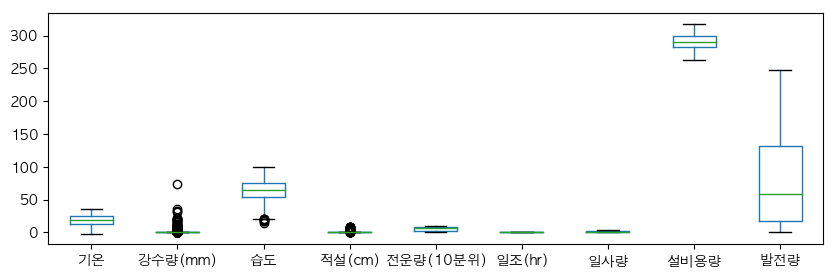

,count,mean,std,min,25%,50%,75%,max
기온,5108.0,18.719479,7.670250,-2.000,12.800,19.1000,24.7000,35.600
강수량(mm),5110.0,0.206419,1.762871,0.000,0.000,0.0000,0.0000,74.600
습도,5110.0,65.166928,15.126223,14.000,54.000,65.0000,76.0000,100.000
적설(cm),5110.0,0.027926,0.392822,0.000,0.000,0.0000,0.0000,8.800
전운량(10분위),5110.0,5.985519,3.686239,0.000,2.000,7.0000,9.0000,10.000
일조(hr),5110.0,0.497162,0.440233,0.000,0.000,0.5000,1.0000,1.000
일사량,5110.0,1.413086,1.054632,0.000,0.470,1.2100,2.2875,3.690
설비용량,5110.0,290.191007,14.075334,263.225,282.355,289.6985,299.6970,318.119
발전량,5110.0,78.277661,67.321926,0.030,17.890,58.8600,131.5250,247.560


In [65]:
fig,ax = plt.subplots(figsize = (10,3))

# NaN 제거 (dropna는 열 기준, row-wise 제거하려면 axis =0)
train.drop(columns=['발전기명', '일시']).dropna().plot(kind='box', ax=ax)
plt.show()

display(train.describe().T)

In [113]:
# 강수량, 습도, 적설 이상치 존재

## 2-3 train 데이터 세트의 발전량과 나머지 변수간의 상관관계를 확인하라

In [66]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일시         5110 non-null   datetime64[ns]
 1   기온         5108 non-null   float64       
 2   강수량(mm)    5110 non-null   float64       
 3   습도         5110 non-null   float64       
 4   적설(cm)     5110 non-null   float64       
 5   전운량(10분위)  5110 non-null   int64         
 6   일조(hr)     5110 non-null   float64       
 7   일사량        5110 non-null   float64       
 8   발전기명       5110 non-null   object        
 9   설비용량       5110 non-null   float64       
 10  발전량        5110 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 439.3+ KB


In [67]:
train['발전량'] = pd.to_numeric(train['발전량'], errors ='coerce')

In [68]:
display(train.drop(columns=['발전기명','일시']).corr()[['발전량']]\
        .sort_values('발전량')[:-1].round(3).T) # 자기자신과의 상관관계를 제거

,전운량(10분위),습도,강수량(mm),적설(cm),설비용량,기온,일조(hr),일사량
발전량,-0.484,-0.383,-0.1,-0.068,-0.021,0.118,0.598,0.857


## 2-4 발전량을 종속변수로 하여 2개의 회귀모델링을 진행하고 모델을 평가하라

In [2]:
# 이상치 제거 : IQR 기반 이상치 제거
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [121]:
train = remove_outliers_iqr(train,'강수량(mm)')

강수량(mm) 이상치 기준: 0.00 ~ 0.00


In [133]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4166 entries, 0 to 4479
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일시         4166 non-null   datetime64[ns]
 1   기온         4166 non-null   float64       
 2   강수량(mm)    4166 non-null   float64       
 3   습도         4166 non-null   float64       
 4   적설(cm)     1850 non-null   float64       
 5   전운량(10분위)  4166 non-null   float64       
 6   일조(hr)     4166 non-null   float64       
 7   일사량        4157 non-null   float64       
 8   발전기명       4166 non-null   object        
 9   설비용량(MW)   4166 non-null   float64       
 10  발전량        3069 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 390.6+ KB


### 결측치 처리

In [69]:
display(train.isna().sum().to_frame().T)
display(test.isna().sum().to_frame().T)

,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전기명,설비용량,발전량
0,0,2,0,0,0,0,0,0,0,0,0


,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전기명,설비용량,발전량
0,0,0,0,0,0,0,0,0,0,0,0


In [129]:
def nandrop(df):
    df = df[df['습도'].notna()].copy() # 습도 안포함 하는 행만 
    df['일사량'] = df['일사량'].fillna(df['일사량'].mean()) # 일사량은 평균 대체
    df = df.drop(columns=['적설(cm)']) # 해당 열 제거
    df = df[df['발전량'].notna()]
    return df

In [130]:
train_df = nandrop(train)
test_df = nandrop(test)

In [71]:
train_df = train[train['기온'].notna()].copy()
test_df = test.copy()

In [72]:
display(train_df.isna().sum().to_frame().T)
display(test_df.isna().sum().to_frame().T)

,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전기명,설비용량,발전량
0,0,0,0,0,0,0,0,0,0,0,0


,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전기명,설비용량,발전량
0,0,0,0,0,0,0,0,0,0,0,0


In [73]:
train_x = train_df.drop(columns=['일시', '발전기명','발전량'])
train_y = train_df['발전량']

test_x = test_df.drop(columns=['일시', '발전기명','발전량'])
test_y = test_df['발전량']

In [74]:
# 쉼표 제거 후 float으로 변환
train_y = train_y.astype(str).str.replace(',', '').astype(float)
test_y = test_y.astype(str).str.replace(',', '').astype(float)

In [75]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [76]:
dt = DecisionTreeRegressor(random_state= 123)
gb = GradientBoostingRegressor(random_state = 123)

In [77]:
dt.fit(train_x, train_y)
gb.fit(train_x, train_y)
dt_predict = dt.predict(test_x)
gb_predict = gb.predict(test_x)

In [80]:
dt_mse = mean_squared_error(test_y, dt_predict)
gb_mse = mean_squared_error(test_y, gb_predict)

dt_r2 = r2_score(test_y, dt_predict)
gb_r2 = r2_score(test_y, gb_predict)

In [81]:
print(f'''
결정트리의 mse값은 {round(dt_mse,3)}, r2스코어는 {round(dt_r2, 3)}이고 
그래디언부스팅의 mse값은 {round(gb_mse,3)}, r2스코어는 {round(gb_r2, 3)}이다. 
그래디언부스팅의 성능이 더 좋은 것을 확인했다.
''')


결정트리의 mse값은 2146.546, r2스코어는 0.604이고 
그래디언부스팅의 mse값은 1324.67, r2스코어는 0.756이다. 
그래디언부스팅의 성능이 더 좋은 것을 확인했다.



In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [83]:
rf = RandomForestRegressor(random_state= 123)
lr = LinearRegression()

In [84]:
rf.fit(train_x, train_y)
lr.fit(train_x, train_y)

LinearRegression()

In [85]:
rf_predict = rf.predict(test_x)
lr_predict = lr.predict(test_x)

In [86]:
rf_mse = mean_squared_error(test_y, rf_predict)
lr_mse = mean_squared_error(test_y, lr_predict)

rf_r2 = r2_score(test_y, rf_predict)
lr_r2 = r2_score(test_y, lr_predict)

In [87]:
print(f'''
랜덤포레스트의 mse값은 {round(rf_mse,3)}, r2스코어는 {round(rf_r2, 3)}이고
선형회귀의 mse값은 {round(lr_mse,3)}, r2스코어는 {round(lr_r2, 3)}이다. 
랜덤포레스트가 성능이 더 좋은 것을 확인했다.
''')


랜덤포레스트의 mse값은 1260.908, r2스코어는 0.768이고
선형회귀의 mse값은 1349.76, r2스코어는 0.751이다. 
랜덤포레스트가 성능이 더 좋은 것을 확인했다.



# 통계 (40점)

## 데이터 설명
- 보스턴 집값 관련 데이터 
    - MEDV(집값) : 종속변수

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv('./data/32/adp32_s1.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT1,LSTAT2,MEDV
0,0.00632,18.0,2.31,0.0,0.538,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,5.0520,24.0
1,0.02731,0.0,7.07,0.0,0.469,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,9.4440,21.6
2,0.02729,0.0,7.07,0.0,0.469,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,3.8970,34.7
3,0.03237,0.0,2.18,0.0,0.458,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,2.9410,33.4
4,0.06905,0.0,2.18,0.0,0.458,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,5.4075,36.2


## 3-1 기본 회귀가정 검토하라

In [141]:
# 선형성 
# 독립성
# 등분산성
# 정규성

In [117]:
import statsmodels.api as sm 

X = df.drop(columns =['MEDV'])
y = df['MEDV']
X = sm.add_constant(X) # 상수항 추가, 선형회귀는 기본적으로 절편을 포함. 수동으로 추가

In [118]:
model = sm.OLS(y,X).fit() # y, X로 최소제곱 선형 회귀 모델 생성, 학습
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     87.03
Date:                Wed, 23 Apr 2025   Prob (F-statistic):          2.09e-118
Time:                        22:43:22   Log-Likelihood:                -1538.2
No. Observations:                 506   AIC:                             3104.
Df Residuals:                     492   BIC:                             3164.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.4437      3.888     17.860      0.000      61.804      77.083
CRIM          -0.1181      0.036     -3.288      0.001      -0.189      -0.048
ZN             0.0657      0.015      4.483      0.000       0.037       0.095
INDUS         -0.0313      0.066     -0.472      0.637      -0.161       0.099
CHAS           2.9475      0.932      3.164      0.002       1.117       4.778
NOX          -20.9226      4.118     -5.081      0.000     -29.014     -12.832
AGE            0.0257      0.014      1.836      0.067      -0.002       0.053
DIS           -1.7140      0.214     -8.011      0.000      -2.134      -1.294
RAD            0.4019      0.071      5.675      0.000       0.263       0.541
TAX           -0.0148      0.004     -3.660      0.000      -0.023      -0.007
PTRATIO       -1.1462      0.140     -8.197      0.000      -1.421      -0.871
B              0.0068      0.003      2.340      0.020       0.001       0.012
LSTAT1        -0.5449      0.557     -0.978      0.329      -1.640       0.550
LSTAT2        -0.2274      0.556     -0.409      0.683      -1.319       0.865
==============================================================================
Omnibus:                      126.656   Durbin-Watson:                   1.246
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              298.364
Skew:                           1.281   Prob(JB):                     1.63e-65
Kurtosis:                       5.754   Cond. No.                     1.28e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.28e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [56]:
# R-squared: 결정계수 (모델 설명력)
# Adj. R-squared: 변수 개수 보정된 설명력
# F-statistic: 모델 전체 유의성 검정
# coef: 각 변수의 회귀계수(기울기)
# P>|t|: 각 계수가 통계적으로 유의미한지를 보여주는 값,
   # 0.05 미만이면 유의미하다고 판단
# [0.025, 0.975]: 회귀계수의 95% 신뢰구간

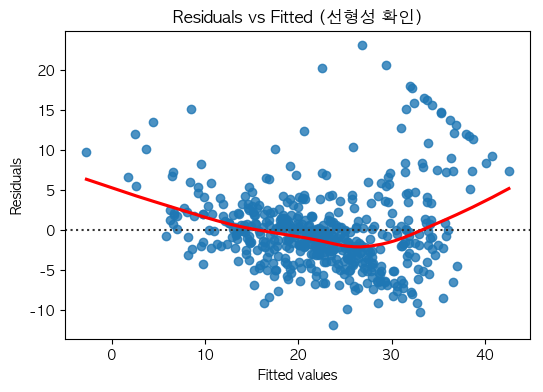


패턴 없이 흩어져 있어야하며 빨간선이 잔차선 (x=0선)을 따라 평평하고 
직선적이어야 선형성 만족
선형성 가정 위반 가능성 있음



In [145]:
import scipy.stats as stats

# 예측값과 잔차
fitted_vals = model.fittedvalues  # 예측값
residuals = model.resid           # 잔차 (y - y_hat)
standardized_resid = model.get_influence().resid_studentized_internal 
# 표준화 잔차

plt.figure(figsize=(6,4))
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (선형성 확인)")
plt.show()

print('''
패턴 없이 흩어져 있어야하며 빨간선이 잔차선 (x=0선)을 따라 평평하고 
직선적이어야 선형성 만족
선형성 가정 위반 가능성 있음
''')

In [146]:
# 빨간 선 : 잔차의 평균적인 추세를 부드럽게 그린 선형 경향선
# 점들이 수평선 주변에 무작위로 퍼져 있음
# 빨간 선이 x축(잔차=0선)을 따라 평평하고 직선적임
# 이 경우, 예측값에 따라 오차가 체계적으로 변하지 않으므로 선형 회귀 가정 만족

In [147]:
resid = model.resid # 회귀 잔차
exog = model.model.exog # 설명 변수 (X)

In [148]:
# 독립성  durbin_watson
from statsmodels.stats.stattools import durbin_watson

durbin_watson(resid) 

# 0~4사이의 값을 가지며 2에 가까울수록 자기상관이 없음(즉, 독립성을 만족한다)
# 1.5보다 작으므로 독립이 아니다. (1.5 < dw < 2.5: 독립성 가정 만족)

1.245613025169312

In [149]:
# 등분산성 breusch-pagan 
# 귀무가설 : 잔차의 분산이 등분산을 만족한다.
# 대립가설 : 등분산성이 아니다 (이분산성 존재)

import statsmodels.stats.api as sms

static , pvalue, f_static , f_pv = sms.het_breuschpagan(resid,exog)
print(pvalue)
# 등분산이 아니다.

1.6419500179640082e-06


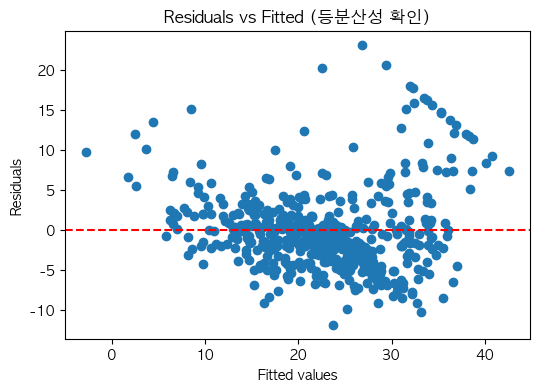

In [150]:
# 등분산성 검토 : 잔차가 퍼진 폭이 일정해야 등분산성 만족
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (등분산성 확인)")
plt.show()

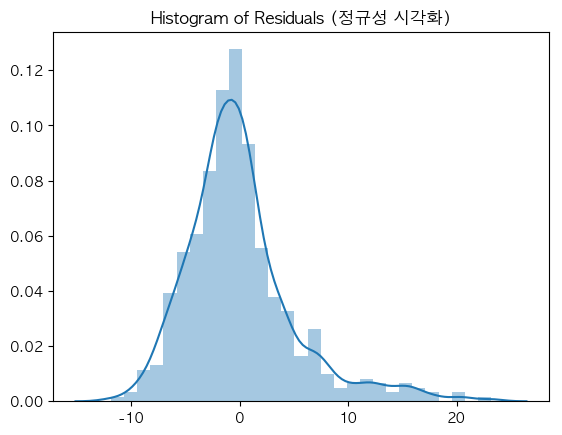

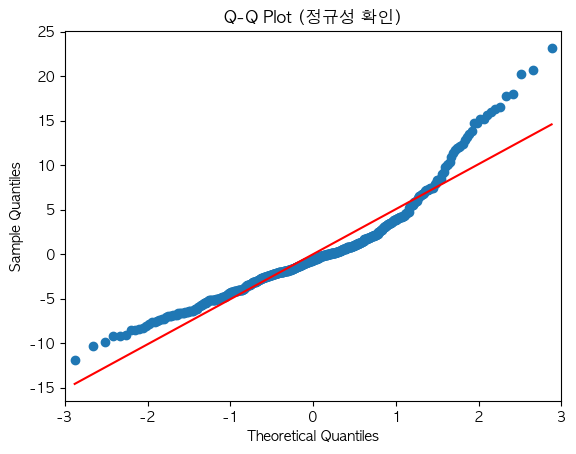

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# 히스토그램
sns.distplot(residuals, hist=True, kde=True)
plt.title("Histogram of Residuals (정규성 시각화)")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot (정규성 확인)")
plt.show()

In [152]:
# Shapiro-Wilk Test
# 귀무가설(H₀): 잔차는 정규분포를 따른다.
# 대립가설(H₁): 잔차는 정규분포를 따르지 않는다.

In [153]:
# 샤피로-윌크 검정
from scipy.stats import shapiro
stat, p = shapiro(resid)
print(f"Shapiro-Wilk Test: W={stat:.3f}, p-value={p:.3f}")
# 정규성 만족하지 않는다.

Shapiro-Wilk Test: W=0.918, p-value=0.000


In [154]:
print('''선형성 - 선형성,독립성,등분산성, 정규성의 경우 
통계검정시 모두 만족하지 않음을 보임''')

선형성 - 선형성,독립성,등분산성, 정규성의 경우 
통계검정시 모두 만족하지 않음을 보임


## 3-2 변수간 관계 검토하고 문제점 해결방안 2가지를 제시하라

In [25]:
# 다중공선성이란?

# 회귀 분석에서 독립 변수들끼리 서로 강한 선형 관계가 있으면,
# → 회귀계수 추정이 불안정해지고
# → 모델 해석이 왜곡되거나, 추론(p-value 등) 결과가 잘못될 수 있음.

# 이걸 "다중공선성 문제"라고 한다.

In [119]:
df.drop(columns=['MEDV']).corr()

,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT1,LSTAT2
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,0.447078
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,-0.413171
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,0.603538
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,-0.050231
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,0.592770
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,0.602661
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,-0.496017
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,0.486448
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,0.542572
PTRATIO,0.289946,-0.391679,0.383248,-0.121515,0.188933,0.261515,-0.232471,0.464741,0.460853,1.000000,-0.177383,0.374044,0.369436


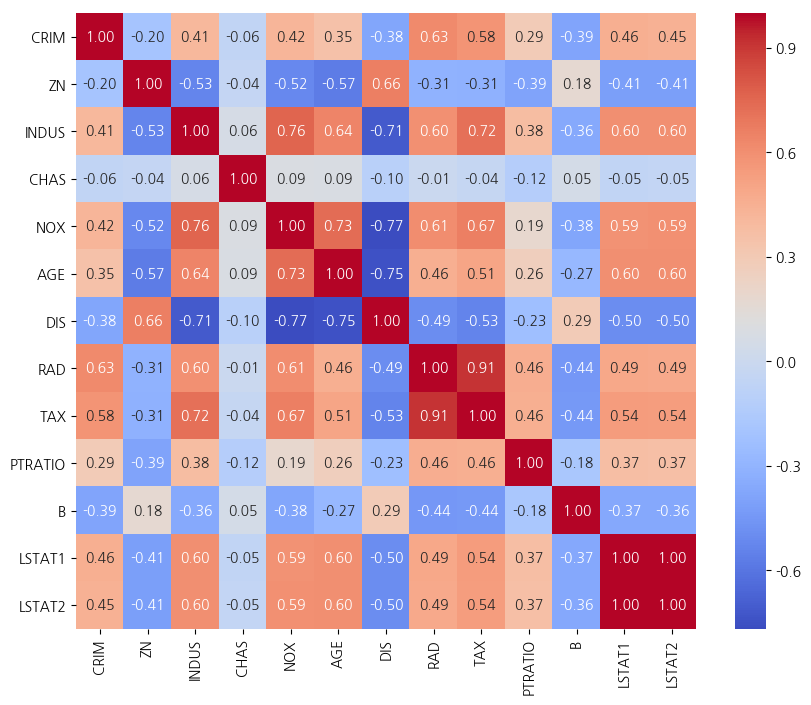

상관관계 히트맵 : LSTAT1과 LSTAT2는 강한 양의상관관계를 가짐을 알 수 있다.


In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.drop(columns=['MEDV']).corr()

# 3. 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()
print('상관관계 히트맵 : LSTAT1와 LSTAT2, TAX와 RAD는 강한 양의상관관계를 가짐을 알 수 있다.')

In [146]:
corr_df = df.drop(columns=['MEDV']).corr().unstack().reset_index()
display(corr_df.head())  # 상관행렬을 길쭉한 데이터 프레임 형태로 변환
corr_df.columns =['col1','col2','corr']
corr_df = corr_df[corr_df['col1']!= corr_df['col2']].sort_values('corr').reset_index(drop=True)
display(corr_df.head()) # 두개씩 같은 행 존재
corr_df = corr_df[::2].sort_values('corr', ascending = False).reset_index(drop=True)  # 중복 제거
display(corr_df)

,level_0,level_1,0
0,CRIM,CRIM,1.000000
1,CRIM,ZN,-0.200469
2,CRIM,INDUS,0.406583
3,CRIM,CHAS,-0.055892
4,CRIM,NOX,0.420972


,col1,col2,corr
0,DIS,NOX,-0.769230
1,NOX,DIS,-0.769230
2,DIS,AGE,-0.747881
3,AGE,DIS,-0.747881
4,DIS,INDUS,-0.708027


,col1,col2,corr
0,LSTAT1,LSTAT2,0.998273
1,TAX,RAD,0.910228
2,INDUS,NOX,0.763651
3,NOX,AGE,0.731470
4,TAX,INDUS,0.720760
...,...,...,...
73,DIS,TAX,-0.534432
74,AGE,ZN,-0.569537
75,DIS,INDUS,-0.708027
76,DIS,AGE,-0.747881


In [147]:
print('''
TAX와 RAD, LSTAT1와 LSTAT2는 강한 양의 상관관계를 가진다. 다중공선성이 발생할 여지가 크기에 이를 해결하기 위해 두가지 접근을 진행한다.
1. 전진선택법을 통해 변수를 선택한다.
2. pca를 이용해서 변수간 선형관계를 줄인 축소된 차원으로 분석을 진행
''')
# [start : stop : step] 인덱싱 슬라이스


TAX와 RAD, LSTAT1와 LSTAT2는 강한 양의 상관관계를 가진다. 다중공선성이 발생할 여지가 크기에 이를 해결하기 위해 두가지 접근을 진행한다.
1. vif값을 기준으로 변수를 제거하는 방식
2. pca를 이용해서 변수간 선형관계를 줄인 축소된 차원으로 분석을 진행



In [143]:
# variance_inflation_factor(exog, index) 
# exo : 독립변수 데이터 (X.values)
# index : 몇 번째 변수에 대해 VIF를 구할지 (열 인덱스)

In [151]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


X = df.drop(columns=['MEDV','LSTAT1','TAX','PTRATIO','NOX'])

# 3. VIF 계산
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. 출력
print("VIF 결과:")
print(vif_df)
print("\n VIF결과 LSTAT1과 LSTAT2에서 매우 큰 VIF 값을 가지며, 'TAX'와 'PTRATIO', 'NOX'도 큰 값을 가진다.")
# ['MEDV','LSTAT1','TAX','PTRATIO','NOX'] 변수 제거 

VIF 결과:
  feature        VIF
0    CRIM   2.084874
1      ZN   2.334699
2   INDUS   9.014491
3    CHAS   1.115179
4     AGE  14.004453
5     DIS   8.446920
6     RAD   4.772997
7       B  13.540411
8  LSTAT2   8.316864

 VIF결과 LSTAT1과 LSTAT2에서 매우 큰 VIF 값을 가지며, 'TAX'와 'PTRATIO', 'NOX'도 큰 값을 가진다.


In [156]:
# 3. 단계적 선택법
import statsmodels.api as sm

def stepwise_selection(X, y):
    selected = []
    remaining = list(X.columns)
    current_score = float('inf')

    while True:
        changed = False

        # 전진 단계
        scores_with_candidates = []
        for candidate in remaining:
            model = sm.OLS(y, sm.add_constant(X[selected + [candidate]])).fit()
            aic = model.aic
            scores_with_candidates.append((aic, candidate))

        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]

        if best_new_score < current_score:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            current_score = best_new_score
            changed = True

        # 후진 단계
        if len(selected) > 1:
            for candidate in selected[:]:
                trial_vars = selected.copy()
                trial_vars.remove(candidate)
                model = sm.OLS(y, sm.add_constant(X[trial_vars])).fit()
                aic = model.aic
                if aic < current_score:
                    selected.remove(candidate)
                    remaining.append(candidate)
                    current_score = aic
                    changed = True

        if not changed:
            break
    return selected

X = df.drop(columns=['MEDV'])
y = df['MEDV']

select_cols = stepwise_selection(X, y)
# 4. 실행
print("최종 선택된 변수:" ,select_cols)

최종 선택된 변수: ['LSTAT1', 'PTRATIO', 'DIS', 'NOX', 'ZN', 'CHAS', 'RAD', 'TAX', 'CRIM', 'B', 'AGE']


## 3-3 앞에서 제안한 것을 반영하여 문제를 해결하고 적용 결과를 제시하라

In [157]:
import statsmodels.api as sm

# 변수 제거를 통한 vif개선
remove_col = ['LSTAT1', 'PTRATIO', 'DIS', 'NOX', 'ZN', 'CHAS', 'RAD', 'TAX', 'CRIM', 'B', 'AGE']


X = df[remove_col]
y = df['MEDV']
X = sm.add_constant(X)

model = sm.OLS(y,X).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     103.2
Date:                Wed, 23 Apr 2025   Prob (F-statistic):          2.45e-120
Time:                        23:07:18   Log-Likelihood:                -1538.4
No. Observations:                 506   AIC:                             3101.
Df Residuals:                     494   BIC:                             3152.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.7816      3.823     18.253      0.000      62.270      77.293
LSTAT1        -0.7753      0.046    -16.955      0.000      -0.865      -0.685
PTRATIO       -1.1526      0.138     -8.360      0.000      -1.423      -0.882
DIS           -1.6983      0.209     -8.128      0.000      -2.109      -1.288
NOX          -21.5501      3.946     -5.461      0.000     -29.303     -13.797
ZN             0.0668      0.015      4.597      0.000       0.038       0.095
CHAS           2.8877      0.925      3.123      0.002       1.071       4.704
RAD            0.4115      0.067      6.098      0.000       0.279       0.544
TAX           -0.0157      0.004     -4.347      0.000      -0.023      -0.009
CRIM          -0.1153      0.035     -3.254      0.001      -0.185      -0.046
B              0.0068      0.003      2.352      0.019       0.001       0.012
AGE            0.0257      0.014      1.844      0.066      -0.002       0.053
==============================================================================
Omnibus:                      125.993   Durbin-Watson:                   1.244
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              294.346
Skew:                           1.279   Prob(JB):                     1.21e-64
Kurtosis:                       5.724   Cond. No.                     1.23e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.23e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [158]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [159]:
X = df.drop(columns = 'MEDV')
X_sc = pd.DataFrame(StandardScaler().fit_transform(X), columns = X.columns)
X_sc.head()

,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT1,LSTAT2
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,-1.067186
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,-0.450909
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,-1.229253
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,-1.363398
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,-1.017303


In [160]:
pca = PCA()
pca_fit = pca.fit(X_sc)

pca_result = pd.DataFrame({'고유값': pca.singular_values_,\
              '분산 설명력': pca.explained_variance_ratio_,\
            '누적 분산 설명력':np.cumsum(pca.explained_variance_ratio_)})
print('주성분 분석 결과')
display(pca_result)

주성분 분석 결과


,고유값,분산 설명력,누적 분산 설명력
0,57.483085,0.502327,0.502327
1,26.863176,0.109704,0.612030
2,23.343546,0.082840,0.694870
3,21.759076,0.071976,0.766846
4,20.178058,0.061896,0.828742
5,18.255859,0.050665,0.879408
6,16.394210,0.040859,0.920267
7,12.771420,0.024796,0.945063
8,11.993180,0.021866,0.966929
9,9.790831,0.014573,0.981502


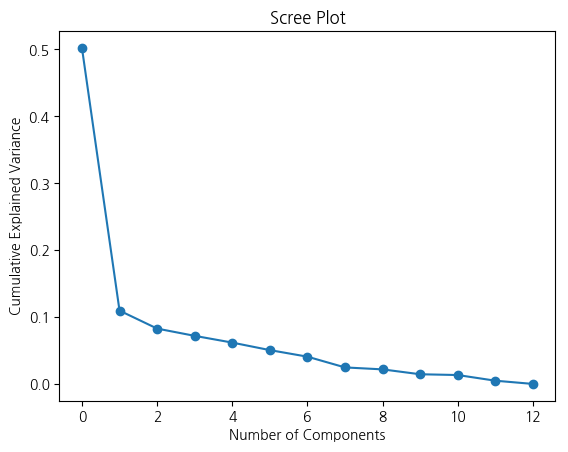

기울기가 급격히 완만해지는 지점, 즉 정보량(분산)의 감소가 작아지는 지점의 주성분을 선택한다.


In [161]:
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.plot(pca.explained_variance_ratio_,'o-')
plt.show()
print("기울기가 급격히 완만해지는 지점, 즉 정보량(분산)의 감소가 작아지는 지점의 주성분을 선택한다.")

In [165]:
pca = PCA(n_components = 5)
pca_df = pca.fit_transform(X_sc)
pca_df = pd.DataFrame(pca_df, columns = ['pca1','pca2','pca3','pca4','pca5'])
pca_df.head()

,pca1,pca2,pca3,pca4,pca5
0,-2.285308,-0.729578,0.375555,0.326918,-1.154364
1,-1.514073,-0.670096,-0.759435,-0.119222,-0.258662
2,-2.166438,-0.525180,-0.218396,-0.774312,-0.645222
3,-2.779610,0.015747,-0.299843,-1.068339,-0.299489
4,-2.479035,-0.053172,-0.547247,-0.770198,-0.123243


In [166]:
X = pca_df
y = df['MEDV']
X = sm.add_constant(X)

model = sm.OLS(y,X).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     169.0
Date:                Wed, 23 Apr 2025   Prob (F-statistic):          5.42e-105
Time:                        23:12:22   Log-Likelihood:                -1589.9
No. Observations:                 506   AIC:                             3192.
Df Residuals:                     500   BIC:                             3217.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5328      0.251     89.942      0.000      22.041      23.025
pca1          -2.2095      0.098    -22.538      0.000      -2.402      -2.017
pca2          -1.6826      0.210     -8.021      0.000      -2.095      -1.270
pca3           3.2401      0.241     13.421      0.000       2.766       3.714
pca4          -1.3880      0.259     -5.359      0.000      -1.897      -0.879
pca5          -2.2325      0.279     -7.994      0.000      -2.781      -1.684
==============================================================================
Omnibus:                      128.545   Durbin-Watson:                   1.086
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              311.608
Skew:                           1.287   Prob(JB):                     2.16e-68
Kurtosis:                       5.856   Cond. No.                         2.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

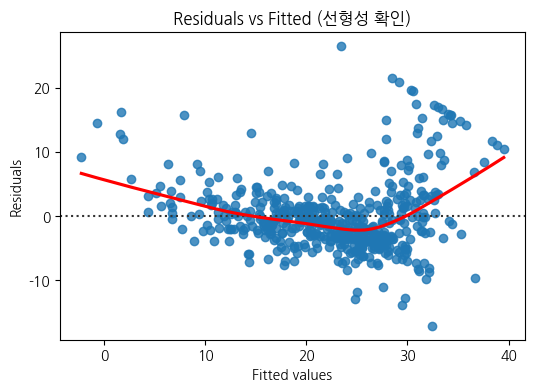

1.0862760385027732
값이 증가했지만 여전히 독립은 아니다.
3.711098624421521e-11
등분산성을 만족하지 않는다.
2.6683865524754185e-17
정규성을 만족하지 않는다.


In [167]:
from statsmodels.stats.diagnostic import linear_rainbow

resid = model.resid  # 회귀 잔차
exog = model.model.exog  # 설명 변수 (X)

import scipy.stats as stats

# 예측값과 잔차
fitted_vals = model.fittedvalues  # 예측값
residuals = model.resid           # 잔차 (y - y_hat)
standardized_resid = model.get_influence().resid_studentized_internal 
# 표준화 잔차

plt.figure(figsize=(6,4))
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (선형성 확인)")
plt.show()
    
# 독립성  durbin_watson
from statsmodels.stats.stattools import durbin_watson
print(durbin_watson(resid)) # 0~4사이의 값을 가지며 2에 가까울수록 자기상관이 없음(독립)
print("값이 증가했지만 여전히 독립은 아니다.")
# 독립이 아니다.


# 등분산성 breusch-pagan 
# 귀무가설 : 잔차의 분산이 일정하다 (등분산이다.)

import statsmodels.stats.api as sms

static , pvalue, f_static , f_pv = sms.het_breuschpagan(resid,exog)
print(pvalue)
print("등분산성을 만족하지 않는다.")
    
# 정규성 - shapiro
# 귀무가설 : 정규성을 따른다

from scipy.stats import shapiro
static ,pv = shapiro(model.resid)
print(pv)
print("정규성을 만족하지 않는다.")

## 데이터 설명 : 차량 정보 데이터
## 4-1 cyl, gear 컬럼으로 교차테이블을 만들어라

In [168]:
df = pd.read_csv('./data/32/adp32_s2.csv')
df.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [169]:
cross_df = pd.crosstab(df['cyl'],df['gear'])  # 빈도수로 
cross_df

gear,3,4,5
cyl,,,
4,1,8,2
6,2,4,1
8,12,0,2


## 4-2 두 범주형 변수 간 차이가 존재하는지 확인하려한다. 귀무가설과 대립가설을 작성하라. 

- 범주형 변수간의 차이를 확인하는 것이므로 카이제곱 독립성 검정을 시행한다.
- 귀무가설 : 두 범주형 변수는 독립이다
- 대립가설 : 독립이 아니다.

## 4-3 통계검정을 실시하고 해석하라

In [171]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(cross_df)

print(f"chi2 : {chi2:.3f}")
print(f"p-value : {p:.4f}")
print("cyl과 gear는 유의수준 5%에서 통계적으로 상관성이 있다. 즉 독립이 아니다.")

chi2 : 18.036
p-value : 0.0012
cyl과 gear는 유의수준 5%에서 통계적으로 상관성이 있다. 즉 독립이 아니다.


## 데이터 설명 : 남녀 급여 데이터

## 5-1 각 성별의 급여 데이터가 정규성을 만족하는 지 확인해라

In [172]:
import pandas as pd
df = pd.read_csv('./data/32/adp32_s3.csv')
df.tail()

,성별,급여
45,여,161.715076
46,여,158.795678
47,여,202.937136
48,여,164.604027
49,여,181.397079


In [173]:
# 귀무가설 : 데이터가 정규성을 만족한다

from scipy.stats import shapiro

b = df[df['성별']=='남']['급여']
g = df[df['성별']=='여']['급여']

b_s , b_p = shapiro(b)
g_s , g_p = shapiro(g)

print(f'''
샤피로 검정은 귀무가설이 "데이터가 정규성을 만족한다."이다. 
검정 결과 남성의 급여에 대한 pvalue는 {round(b_p,3)}으로 유의수준 0.05하에 귀무가설을 기각하지 못한다. 즉 정규성을 만족한다.
검정 결과 여성의 급여에 대한 pvalue는 {round(g_p,6)}으로 유의수준 0.05하에 귀무가설을 기각하고 대립가설을 채택한다. 즉 정규성을 만족하지 않는다.
''')


샤피로 검정은 귀무가설이 "데이터가 정규성을 만족한다."이다. 
검정 결과 남성의 급여에 대한 pvalue는 0.406으로 유의수준 0.05하에 귀무가설을 기각하지 못한다. 즉 정규성을 만족한다.
검정 결과 여성의 급여에 대한 pvalue는 5e-06으로 유의수준 0.05하에 귀무가설을 기각하고 대립가설을 채택한다. 즉 정규성을 만족하지 않는다.



## 5-2 위 결과에 맞는 남녀 월급 차이가 있는지 확인하기 위한 검정 전략을 설명하라

- 여성 급여가 정규성을 만족하지 못하므로 비모수 검정을 시행해야한다. 
- 비모수 검정법 중 맨 휘트니 검정을 시행한다.

## 5-3 가설에 따른 검정을 수행하고 검정통계량과 p-value를 설명하라

In [174]:
from scipy.stats import mannwhitneyu

m_s, m_p = mannwhitneyu(b,g)
print(f'''
맨휘트니 가설검정 결과 검정 통계량은 {round(m_s,7)}, pvalue는 {round(m_p,7)}이다. 
유의수준 0.05하에서 귀무가설인 "두 집단의 분포가 동일하다"를 기각한다.
즉 두 집단의 분포가 동일하다 볼 수 없다.
''')


맨휘트니 가설검정 결과 검정 통계량은 586.0, pvalue는 1e-07이다. 
유의수준 0.05하에서 귀무가설인 "두 집단의 분포가 동일하다"를 기각한다.
즉 두 집단의 분포가 동일하다 볼 수 없다.

